In [1]:
import sys
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from src.core.config import Config
Config.ensure_dirs()

## 1. Top 30 do Ranking Multi-Critério

O score combina cobertura ao longo do traçado (peso 0.5), volume de viagens diárias (peso 0.3) e adequação do comprimento da rota (peso 0.2).

In [2]:
ranking_path = Config.LINE_RANKING_PATH
df_ranking = pd.read_csv(ranking_path)

print(f"Total de linhas avaliadas: {len(df_ranking)}")
top30_cols = [
    "route_id", "route_long_name", "coverage_pct_min", "weekday_trips",
    "peak_headway_min", "length_km_mean", "dominant_station_id", "score", "exclusion_reason"
]
df_ranking.head(30)[top30_cols]

Total de linhas avaliadas: 1309


,route_id,route_long_name,coverage_pct_min,weekday_trips,peak_headway_min,length_km_mean,dominant_station_id,score,exclusion_reason
0,2202-10,Jd. Das Oliveiras - Cptm Guaianases,1.000000,664,2.75,10.545,355030810A,0.999771,selecionada
1,3064-10,Cid. Tiradentes - Cptm Guaianases,1.000000,430,5.00,10.270,355030802A,0.996218,selecionada
2,1705-10,Jd. São João - Metrô Tucuruvi,1.000000,384,5.75,8.335,355030813A,0.993239,selecionada
3,3026-10,Vl. Iolanda Ii - Cptm Guaianases,1.000000,358,5.75,10.035,355030806A,0.990374,selecionada
4,746P-10,Paraisópolis - Sto. Amaro,1.000000,325,6.25,9.680,355030894A,0.986020,selecionada
5,1709-10,Jd. Joana D'arc - Metrô Tucuruvi,0.977778,337,5.75,8.795,355030813A,0.977430,estacao_dominante_repetida_355030813A
6,1702-10,Jova Rural - Tietê,1.000000,288,6.50,15.540,355030813A,0.977196,estacao_dominante_repetida_355030813A
7,4734-10,Vl. Moraes - Metrô Saúde,0.951220,478,4.25,8.540,355030856A,0.974235,selecionada
8,9032-10,Jd. Damasceno - Term. Cachoeirinha,1.000000,266,7.25,10.080,355030817A,0.970435,selecionada
9,9784-10,Jd. Dos Francos - Metrô Barra Funda,0.970588,300,6.50,13.190,355030872A,0.966960,selecionada


## 2. Histograma da Cobertura Pluviométrica

Distribuição da cobertura mínima entre os sentidos das linhas por estações ativas (raio de 2.000 metros).

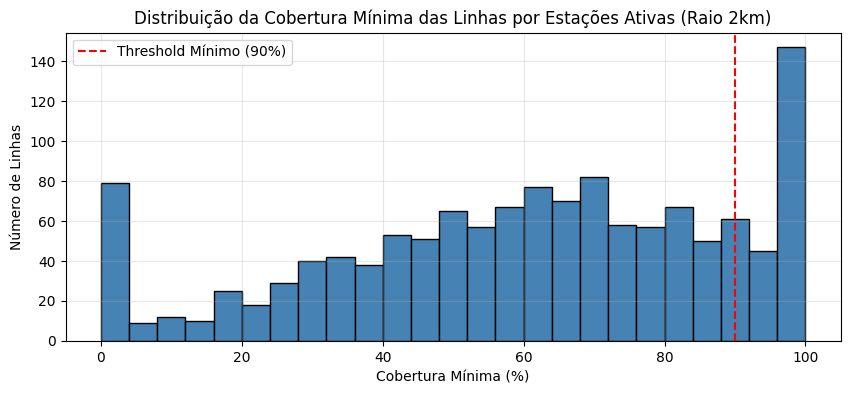

In [3]:
plt.figure(figsize=(10, 4))
plt.hist(df_ranking["coverage_pct_min"] * 100, bins=25, color="steelblue", edgecolor="black")
plt.title("Distribuição da Cobertura Mínima das Linhas por Estações Ativas (Raio 2km)")
plt.xlabel("Cobertura Mínima (%)")
plt.ylabel("Número de Linhas")
plt.axvline(90, color="red", linestyle="--", label="Threshold Mínimo (90%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Tabela Final das 8 Linhas Selecionadas

Linhas validadas com a API Olho Vivo, com código de linha (codigoLinha) resolvido para ambos os sentidos e veículos ativos confirmados em tempo real.

In [4]:
selected_json_path = Config.SELECTED_LINES_PATH
with open(selected_json_path, "r", encoding="utf-8") as f:
    selected_data = json.load(f)

selected_rows = []
for line in selected_data["lines"]:
    for d in line["directions"]:
        selected_rows.append({
            "route_id": line["route_id"],
            "route_long_name": line["route_long_name"],
            "direction_id": d["direction_id"],
            "codigoLinha": d["codigoLinha"],
            "sl": d["sl"],
        })

df_selected = pd.DataFrame(selected_rows)
df_selected


,route_id,route_long_name,direction_id,codigoLinha,sl,headsign,length_km,weekday_trips,peak_headway_min,scheduled_speed_kmh,coverage_pct,dominant_station_id,n_vehicles_seen
0,2202-10,Jd. Das Oliveiras - Cptm Guaianases,0,33678,2,Cptm Guaianases,11.03,664,3.0,8.27,1.0000,355030810A,12
1,2202-10,Jd. Das Oliveiras - Cptm Guaianases,1,910,1,Jd. Das Oliveiras,10.06,664,2.5,10.06,1.0000,355030810A,7
2,3064-10,Cid. Tiradentes - Cptm Guaianases,0,33748,2,Cptm Guaianases,9.73,430,5.0,10.24,1.0000,355030802A,5
3,3064-10,Cid. Tiradentes - Cptm Guaianases,1,980,1,Cid. Tiradentes,10.81,430,5.0,9.01,1.0000,355030820A,5
4,1705-10,Jd. São João - Metrô Tucuruvi,0,33617,2,Metrô Tucuruvi,8.53,384,6.0,7.21,1.0000,355030813A,5
5,1705-10,Jd. São João - Metrô Tucuruvi,1,849,1,Jd. São João,8.14,384,5.5,7.63,1.0000,355030813A,13
6,3026-10,Vl. Iolanda Ii - Cptm Guaianases,0,33730,2,Cptm Guaianases,9.86,358,6.0,9.39,1.0000,355030806A,4
7,3026-10,Vl. Iolanda Ii - Cptm Guaianases,1,962,1,Vl. Iolanda Ii,10.21,358,5.5,8.88,1.0000,355030806A,7
8,746P-10,Paraisópolis - Sto. Amaro,0,33556,2,Sto. Amaro,9.79,325,6.0,8.39,1.0000,355030894A,5
9,746P-10,Paraisópolis - Sto. Amaro,1,788,1,Paraisópolis,9.57,325,6.5,7.56,1.0000,355030894A,5
